# Transformational AI: Analyzing Ecommerce Large Datasets for Machine Learning

**Author:** Dennis O'Higgins

Welcome to your journey as a data scientist at Transformational AI, where you will play a pivotal role in shaping the future of our company's machine learning models. In this project, you will leverage two Amazon Reviews 2023 datasets, originally sourced from Hugging Face, to perform data transformation, analysis, and visualization. Through this notebook, you will gain hands-on experience with pandas DataFrames and explore powerful data visualization techniques using `seaborn` and `matplotlib`. You will also learn to export your cleaned and processed data into `.csv` and `.parquet` formats, ready for advanced machine learning tasks.

This project reinforces core concepts that you will need to know for your upcoming PCEP exam.

## Part 1: Preparing the Environment
### Part 1.1: Learn about Jupyter Notebooks & Python Virtual Environments

When working with Python for a company, organization, or personal project, it's essential to initialize your Python environment properly. Remember from the course the concept of a Python "virtual environment." This isolated environment allows you to write functions, store variables, work with data, and perform many other operations without interfering with other projects or the system Python environment.

Python is a versioned language, and software packages are versioned as well. Let's check which version of Python and which version of Jupyter Notebook are installed. Run the following commands to check these values:

In [1]:
# Check which version of Python is installed
!python --version

Python 3.14.8


In [2]:
# Check which version of Jupyter Notebook you are using
!jupyter-notebook --version

7.6.3


### Part 1.2: Set Up the Jupyter Notebook

For your work in this notebook, you will need the following packages:

* `datasets`: Provides access to a wide range of datasets, including the Amazon Reviews 2023 dataset we'll be using.
* `pandas`: A powerful data manipulation and analysis library that makes working with structured data easy with Python.
* `matplotlib`: A comprehensive library for creating static, animated, and interactive visualizations in Python.
* `seaborn`: Built on top of matplotlib, seaborn provides a high-level interface for drawing attractive and informative statistical graphics.
* `pyarrow`: A fast and efficient library for reading and writing data in the Apache Arrow format, like Parquet and Feather.

Note: If you see a message like `ERROR: pip's dependency resolver does not currently take into account all the packages that are installed....` do not worry. As long as you see `Successfully installed...` at the end (or `Requirement already satisfied`), the packages are ready.

In [3]:
# Install all of the required packages in one go
!pip install "datasets<4.0.0" pandas matplotlib seaborn pyarrow

  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)


  Using cached multiprocess-0.70.16-py312-none-any.whl.metadata (7.2 kB)


Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached multiprocess-0.70.16-py312-none-any.whl (146 kB)


  Attempting uninstall: dill
    Found existing installation: dill 0.4.1


    Uninstalling dill-0.4.1:
      Successfully uninstalled dill-0.4.1


  Attempting uninstall: multiprocess


    Found existing installation: multiprocess 0.70.19
    Uninstalling multiprocess-0.70.19:
      Successfully uninstalled multiprocess-0.70.19
   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [multiprocess]

   ━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━ 1/2 [multiprocess]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [multiprocess]


## Part 2: Download the Reviews Dataset
### Part 2.1: Learn about Working with Big Data

In this part, we will load the `Electronics` dataset using the Hugging Face `datasets` library. The full dataset is 22.6 GB, so we will take a small subset and stream it rather than download all of it.

### Part 2.2: Download and visualize the reviews dataset with `pandas`

Steps to complete:

* Set the `sample_limit` to an integer value of 100 so that no more than 100 data items will be collected from the dataset
* Create a for loop so that you increment up to 100 data samples and then break
* Use boolean operators to set the missing `load_dataset` parameters to `True`

In [4]:
from datasets import load_dataset
import pandas as pd

# Load the reviews dataset
reviews_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_review_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
)

# Initialize an empty list to collect review samples
reviews = []

# Limit the number of data samples collected
sample_limit = 100

# Iterate over the reviews dataset and collect samples
for i, review in enumerate(reviews_dataset):
    if i >= sample_limit:
        break
    reviews.append(review)

# Convert the list of review samples to a pandas DataFrame
reviews_df = pd.DataFrame(reviews)

# Print the dataframe
reviews_df

/content/v314/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,3.0,Smells like gasoline! Going back!,First & most offensive: they reek of gasoline ...,[{'small_image_url': 'https://m.media-amazon.c...,B083NRGZMM,B083NRGZMM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1658185117948,0,True
1,1.0,Didn’t work at all lenses loose/broken.,These didn’t work. Idk if they were damaged in...,[],B07N69T6TM,B07N69T6TM,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1592678549731,0,True
2,5.0,Excellent!,I love these. They even come with a carry case...,[],B01G8JO5F2,B01G8JO5F2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1523093017534,0,True
3,5.0,Great laptop backpack!,I was searching for a sturdy backpack for scho...,[],B001OC5JKY,B001OC5JKY,AGGZ357AO26RQZVRLGU4D4N52DZQ,1290278495000,18,True
4,5.0,Best Headphones in the Fifties price range!,I've bought these headphones three times becau...,[],B013J7WUGC,B07CJYMRWM,AG2L7H23R5LLKDKLBEF2Q3L2MVDA,1676601581238,0,True
...,...,...,...,...,...,...,...,...,...,...
95,5.0,16g cork usb,it worked fine / great conversation piece too!,[],B018S7DPU8,B018S7DPU8,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1538613893334,0,True
96,5.0,Five Stars,perfect item for a novices user as I am. . .,[],B00MYU0E0K,B00MYU0E0K,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1533024545470,0,True
97,5.0,Five Stars,Great hard drive for the price! Installed with...,[],B000Q85WOK,B000Q85WOK,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1532072088895,0,True
98,5.0,Five Stars,Great little device!,[],B01KWY71BO,B01KWY71BO,AEFKF6R2GUSK2AWPSWRR4ZO36JVQ,1532071758130,0,True


**Let's Reflect...**

Question 1: Describe the data that you see. What are the columns, what data types do you see, and how are the reviews structured?

The answer cell below builds the response from the DataFrame itself, so the column names and data types it reports are the ones in your run.

In [5]:
Question1 = (
    f"The reviews DataFrame has {reviews_df.shape[0]} rows and {reviews_df.shape[1]} columns. "
    "Each row is one customer review of an electronics product. The columns and their pandas data types are: "
    + ", ".join(f"{col} ({reviews_df[col].dtype})" for col in reviews_df.columns)
    + ". Numeric columns hold the star rating, the count of helpful votes and the timestamp. "
    "Text (string) columns hold the review title and review body, plus identifiers such as the product ASIN, "
    "parent ASIN and user ID. The images column holds a Python object (a list of images attached to a review), "
    "and the verified purchase column is a boolean. The reviews are structured as one record per review, "
    "linked to a product through its ASIN."
)

if len(Question1) > 0:
    print(f"Question answered! You wrote: {Question1}")
else:
    print("Please answer the question")

Question answered! You wrote: The reviews DataFrame has 100 rows and 10 columns. Each row is one customer review of an electronics product. The columns and their pandas data types are: rating (float64), title (object), text (object), images (object), asin (object), parent_asin (object), user_id (object), timestamp (int64), helpful_vote (int64), verified_purchase (bool). Numeric columns hold the star rating, the count of helpful votes and the timestamp. Text (string) columns hold the review title and review body, plus identifiers such as the product ASIN, parent ASIN and user ID. The images column holds a Python object (a list of images attached to a review), and the verified purchase column is a boolean. The reviews are structured as one record per review, linked to a product through its ASIN.


### Part 2.3: Analyze the reviews dataset with `.head()` from `pandas`

The `.head()` method from `pandas` prints the DataFrame in a plain text format, which is useful for quickly inspecting the first few rows without overwhelming the display.

In [6]:
print(reviews_df.head())

   rating                                        title  \
0     3.0            Smells like gasoline! Going back!   
1     1.0      Didn’t work at all lenses loose/broken.   
2     5.0                                   Excellent!   
3     5.0                       Great laptop backpack!   
4     5.0  Best Headphones in the Fifties price range!   

                                                text  \
0  First & most offensive: they reek of gasoline ...   
1  These didn’t work. Idk if they were damaged in...   
2  I love these. They even come with a carry case...   
3  I was searching for a sturdy backpack for scho...   
4  I've bought these headphones three times becau...   

                                              images        asin parent_asin  \
0  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM   
1                                                 []  B07N69T6TM  B07N69T6TM   
2                                                 []  B01G8JO5F2  B01G8JO5

**Let's Reflect...**

Question 2: What do you think of this output above - was this what you expected? Why or why not?

In [7]:
Question2 = (
    "Yes, mostly. I expected a table of reviews with a rating, a title, the review text and product identifiers, "
    "and that is what .head() shows: the first five reviews, indexed 0 to 4. What I did not expect is that the "
    "plain text output splits the columns across several blocks because the DataFrame is wide, which makes it "
    "harder to read a whole review on one line. That is useful to know, and it is what the next step "
    "(changing the pandas display options) is designed to fix."
)

if len(Question2) > 0:
    print(f"Question answered! You wrote: {Question2}")
else:
    print("Please answer the question")

Question answered! You wrote: Yes, mostly. I expected a table of reviews with a rating, a title, the review text and product identifiers, and that is what .head() shows: the first five reviews, indexed 0 to 4. What I did not expect is that the plain text output splits the columns across several blocks because the DataFrame is wide, which makes it harder to read a whole review on one line. That is useful to know, and it is what the next step (changing the pandas display options) is designed to fix.


### Part 2.4: Transform the DataFrame to be more visually readable

Set some options for how `pandas` will output the DataFrame, such as `max_columns`, `width` and `max_colwidth`.

Steps to complete:

* Set the `Items_To_Print` value to an integer of `10` so that we only output the first 10 items of the DataFrame, overwriting pandas' default output.

In [8]:
import pandas as pd

Items_To_Print = 10

# Adjust display options for better readability
pd.set_option('display.max_columns', None)  # Display all columns
pd.set_option('display.width', 1000)        # Set a larger display width
pd.set_option('display.max_colwidth', 50)   # Set max column width for better readability

# Assuming reviews_df is your DataFrame
print(reviews_df.head(Items_To_Print))

   rating                                        title                                               text                                             images        asin parent_asin                       user_id      timestamp  helpful_vote  verified_purchase
0     3.0            Smells like gasoline! Going back!  First & most offensive: they reek of gasoline ...  [{'small_image_url': 'https://m.media-amazon.c...  B083NRGZMM  B083NRGZMM  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1658185117948             0               True
1     1.0      Didn’t work at all lenses loose/broken.  These didn’t work. Idk if they were damaged in...                                                 []  B07N69T6TM  B07N69T6TM  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  1592678549731             0               True
2     5.0                                   Excellent!  I love these. They even come with a carry case...                                                 []  B01G8JO5F2  B01G8JO5F2  AFKZENTNBQ7A7V7UXW5JJI6UGRYQ  15230930175

**Let's Reflect...**

Question 3: Describe what we did to the pandas DataFrame in order to change how the outputs are reflected.

In [9]:
Question3 = (
    "I changed the pandas display options with pd.set_option. I set display.max_columns to None so every column "
    "is shown instead of being hidden behind an ellipsis, display.width to 1000 so each row fits on one line "
    "instead of wrapping into blocks, and display.max_colwidth to 50 so long text such as review bodies is "
    "truncated to a readable length. I also set Items_To_Print to 10 and passed it to .head(), so the output "
    "shows the first ten rows rather than the default five. The underlying data is unchanged; only the way it "
    "is displayed is different."
)

if len(Question3) > 0:
    print(f"Question answered! You wrote: {Question3}")
else:
    print("Please answer the question")

Question answered! You wrote: I changed the pandas display options with pd.set_option. I set display.max_columns to None so every column is shown instead of being hidden behind an ellipsis, display.width to 1000 so each row fits on one line instead of wrapping into blocks, and display.max_colwidth to 50 so long text such as review bodies is truncated to a readable length. I also set Items_To_Print to 10 and passed it to .head(), so the output shows the first ten rows rather than the default five. The underlying data is unchanged; only the way it is displayed is different.


## Part 3: Download the Reviews Metadata Dataset
### Part 3.1: Download and visualize the reviews metadata dataset with `pandas`

This is a different dataset, scoped on the metadata around the reviews. It gives us more information about the products themselves, such as price.

Steps to complete:

* Set the `metadata_limit` to an integer value of 100 so that no more than 100 data items will be collected from the dataset
* Create a for loop so that you increment up to 100 data samples and then break
* Use boolean operators to set the missing `load_dataset` parameters to `True`

In [10]:
from datasets import load_dataset, Value
import pandas as pd

# The dataset's loading script declares the `images` and `videos` fields as a Sequence of
# dictionaries, but each record stores them as a list of dictionaries. Arrow cannot cast
# between the two while streaming, so declare both fields as lists of dictionaries.
metadata_features = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True
).features.copy()
metadata_features["images"] = [{"hi_res": Value("string"), "large": Value("string"), "thumb": Value("string"), "variant": Value("string")}]
metadata_features["videos"] = [{"title": Value("string"), "url": Value("string"), "user_id": Value("string")}]

# Load the item metadata dataset
item_metadata_dataset = load_dataset(
    "McAuley-Lab/Amazon-Reviews-2023",
    "raw_meta_Electronics",
    split="full",
    streaming=True,
    trust_remote_code=True,
    features=metadata_features
)

# Initialize an empty list to collect item metadata samples
metadata = []

# Limit to 100 samples
metadata_limit = 100

# Iterate over the metadata dataset and collect samples
for i, item in enumerate(item_metadata_dataset):
    if i >= metadata_limit:
        break
    metadata.append(item)

# Convert the list of item metadata samples to a pandas DataFrame
item_metadata_df = pd.DataFrame(metadata)

# Print the dataframe
item_metadata_df

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,None,"[{'hi_res': None, 'large': 'https://m.media-am...",[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{""Date First Available"": ""August 2, 2014"", ""Ma...",B00MCW7G9M,None,None,None
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],None,[{'hi_res': 'https://m.media-amazon.com/images...,[],SIIG,"[Electronics, Television & Video, Accessories,...","{""Product Dimensions"": ""0.83 x 4.17 x 2.05 inc...",B00YT6XQSE,None,None,None
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,[{'hi_res': 'https://m.media-amazon.com/images...,"[{'title': 'AL 2Sides Video', 'url': 'https://...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{""Brand"": ""Digi-Tatoo"", ""Color"": ""Fresh Marble...",B07SM135LS,None,None,None
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,[{'hi_res': 'https://m.media-amazon.com/images...,[],NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{""Date First Available"": ""May 29, 2020"", ""Manu...",B089CNGZCW,None,None,None
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,"[{'hi_res': None, 'large': 'https://m.media-am...",[],Verizon,"[Electronics, Computers & Accessories, Compute...","{""Product Dimensions"": ""11.6 x 6.9 x 3.1 inche...",B004E2Z88O,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,All Electronics,LaCie Rugged All-Terrain Safe 500 GB USB 2.0/F...,3.2,18,"[Biometric authentication: up to ten users, 12...","[Product Description, The LaCie Rugged Safe is...",146.99,"[{'hi_res': None, 'large': 'https://m.media-am...",[],LaCie,"[Electronics, Computers & Accessories, Data St...","{""Product Dimensions"": ""5.7 x 3.5 x 1 inches"",...",B003XT6OTG,None,None,None
96,Car Electronics,SSV Works Polaris Ranger XP9 900 2012-up and F...,5.0,1,[New],"[Fitment: (2015+) Polaris Ranger, (2013+) Rang...",None,[{'hi_res': 'https://m.media-amazon.com/images...,[],SSV Works,"[Electronics, Car & Vehicle Electronics, Car E...","{""Item Weight"": ""5 pounds"", ""Package Dimension...",B00O2IZZC4,None,None,None
97,Industrial & Scientific,"Monsoon G1/4"" to 1/2"" ID, 3/4"" OD Chain Gun Co...",5.0,1,[],[],25.71,[{'hi_res': 'https://m.media-amazon.com/images...,[],Monsoon,"[Electronics, Computers & Accessories, Compute...","{""Item Dimensions LxWxH"": ""3.94 x 1.97 x 1.97 ...",B00M9AEJQA,None,None,None
98,Camera & Photo,YEELE 6x4ft Galaxy Backdrop Purple Night Sky i...,4.8,19,[],[],None,[{'hi_res': 'https://m.media-amazon.com/images...,[],Yeele,"[Electronics, Camera & Photo, Lighting & Studi...","{""Package Dimensions"": ""14 x 13 x 0.6 inches"",...",B07XCWMSSY,None,None,None


**Let's Reflect...**

Question 4: Compare the Reviews Metadata dataset and the Reviews dataset that you analyzed earlier. What are the differences between the 2 datasets?

In [11]:
_reviews_only = [c for c in reviews_df.columns if c not in item_metadata_df.columns]
_metadata_only = [c for c in item_metadata_df.columns if c not in reviews_df.columns]
_shared = [c for c in reviews_df.columns if c in item_metadata_df.columns]

Question4 = (
    "The two datasets describe different things. The reviews dataset is about customer behaviour: each row is "
    "one review, with columns only it contains (" + ", ".join(_reviews_only) + "). "
    "The metadata dataset is about the products: each row is one product, with columns only it contains ("
    + ", ".join(_metadata_only) + "). "
    "The columns they share are (" + ", ".join(_shared) + "), and the product identifier is the key that can be used "
    "to link a review to its product. The metadata has the information we need for this project, "
    "namely the product title, the average rating and the price, which the reviews dataset does not have."
)

if len(Question4) > 0:
    print(f"Question answered! You wrote: {Question4}")
else:
    print("Please answer the question")

Question answered! You wrote: The two datasets describe different things. The reviews dataset is about customer behaviour: each row is one review, with columns only it contains (rating, text, asin, user_id, timestamp, helpful_vote, verified_purchase). The metadata dataset is about the products: each row is one product, with columns only it contains (main_category, average_rating, rating_number, features, description, price, videos, store, categories, details, bought_together, subtitle, author). The columns they share are (title, images, parent_asin), and the product identifier is the key that can be used to link a review to its product. The metadata has the information we need for this project, namely the product title, the average rating and the price, which the reviews dataset does not have.


### Part 3.2: Analyze the reviews metadata dataset with `.head()` from pandas

In [12]:
print(item_metadata_df.head(10))

               main_category                                              title  average_rating  rating_number                                           features                                        description  price                                             images                                             videos            store                                         categories                                            details parent_asin bought_together subtitle author
0            All Electronics             FS-1051 FATSHARK TELEPORTER V3 HEADSET             3.5              6                                                 []  [Teleporter V3 The “Teleporter V3” kit sets a ...   None  [{'hi_res': None, 'large': 'https://m.media-am...                                                 []        Fat Shark   [Electronics, Television & Video, Video Glasses]  {"Date First Available": "August 2, 2014", "Ma...  B00MCW7G9M            None     None   None
1            All Electronics  

Notice that when we use the `.head()` method, our `pandas` output preferences were saved, because settings are preserved throughout the environment.

### Part 3.3: Safeguarding Data Access with Large Datasets

Data analysis usually involves looking up specific information within the larger data context. This can lead to errors if the data isn't formatted correctly or is missing. Here we review the items with and without a price, and finish the `get_product` lookup function by handling the case where the product title is not found, using a `try-except` block.

In [13]:
import pandas as pd

# Ensure the 'price' column is converted to numeric, setting errors='coerce' to handle non-numeric values
item_metadata_df['price'] = pd.to_numeric(item_metadata_df['price'], errors='coerce')

# Identify products with 'None' or non-float prices
none_price_products = item_metadata_df[item_metadata_df['price'].isna()][['title', 'price']]
valid_price_products = item_metadata_df[item_metadata_df['price'].notna()][['title', 'price']]

# Print the list of products with 'None' or non-float prices
print(f"❌ Products with no valid price listed (Total: {len(none_price_products)})")
for i, row in enumerate(none_price_products.itertuples(index=False), start=1):
    print(f"{i}. {row.title} - Price: {row.price}")

# Print the list of products with valid prices
print(f"\n✅ Products with valid price listed (Total: {len(valid_price_products)})")
for i, row in enumerate(valid_price_products.itertuples(index=False), start=1):
    print(f"{i}. {row.title} - Price: {row.price}")

❌ Products with no valid price listed (Total: 56)
1. FS-1051 FATSHARK TELEPORTER V3 HEADSET - Price: nan
2. Ce-H22B12-S1 4Kx2K Hdmi 4Port - Price: nan
3. Raymarine Wi-Fish DownVision Blackbox Sonar with Wi-Fi - Price: nan
4. Protech iPhone 4 microscope 60X Lens with illumination Led - Price: nan
5. MOSISO Plastic Hard Shell Case & Keyboard Cover Compatible MacBook Air 11 Inch (Models: A1370 & A1465), Transparent Black - Price: nan
6. Network Magic 4.0 - Price: nan
7. Dock Audio Extender Adapter Converter Cable for iPod iPhone 4 4S iPhone 5 5S iPad, Samsung & Other Smart Phones - Price: nan
8. NANW Bands Compatible with Fitbit Versa/Versa 2/Versa Lite Small Large, Soft Silicone Replacement Band for Versa/Versa 2, Air Hole Wristband Strap for Women Men - Price: nan
9. eForCity Leather Case with Stand for 7-Inch Samsung Galaxy Tab 2, White/Black Zebra (PSAMGLXTLC26) - Price: nan
10. KEiiD PC Computer Speaker Compact Bluetooth Stereo System with Aluminum Housing for Laptop Desktop PC Gamin

Create a product lookup function with exception handling

In [14]:
# Function to get the price of a product by its title
def get_product(product_title):
    try:
        # Attempt to find the price of the product
        price = item_metadata_df.loc[item_metadata_df['title'] == product_title, 'price'].values[0]
        if pd.isna(price):
            return "❌ No valid price listed"
        return price
    except IndexError:
        # Handle the case where the product title is not found
        return f"❌ Product not found: '{product_title}'"

Test the product lookup function (known product title). Check a specific item in the DataFrame with a lookup. The first title below is taken from the data you loaded, so the lookup is guaranteed to be a known product.

In [15]:
known_title = item_metadata_df['title'].dropna().iloc[0]
print(f"\nPrice of '{known_title}': {get_product(known_title)}")


Price of 'FS-1051 FATSHARK TELEPORTER V3 HEADSET': ❌ No valid price listed


Test the product lookup function (unknown product title)

In [16]:
unknown_title = "Smart Phone Tripod Holder (Mobile Version)"
print(f"Price of '{unknown_title}': {get_product(unknown_title)}")

Price of 'Smart Phone Tripod Holder (Mobile Version)': ❌ Product not found: 'Smart Phone Tripod Holder (Mobile Version)'


Above, you can see how we can handle data access errors gracefully. By implementing exception handling in the `get_product` function, you can manage cases where the product title is not found or the price is missing, ensuring your code is robust and reliable.

## Part 4: Comparing our Datasets Together
### Part 4.1 Review the columns of the Datasets with `.columns`

Steps to complete: place the right variable in the right spot, `reviews_df.columns` and `item_metadata_df.columns`.

In [17]:
print("Reviews DataFrame columns:", reviews_df.columns)
print("-------------------")
print("Metadata DataFrame columns:", item_metadata_df.columns)

Reviews DataFrame columns: Index(['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase'], dtype='object')
-------------------
Metadata DataFrame columns: Index(['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'subtitle', 'author'], dtype='object')


The above is helpful, but a bit messy to read. Let's use a for loop to iterate over the columns so that they are outputted as a list.

In [18]:
print("Reviews DataFrame columns:")
for column in reviews_df.columns:
    print(f"- {column}")

print("-------------------")

print("Metadata DataFrame columns:")
for column in item_metadata_df.columns:
    print(f"- {column}")

Reviews DataFrame columns:
- rating
- title
- text
- images
- asin
- parent_asin
- user_id
- timestamp
- helpful_vote
- verified_purchase
-------------------
Metadata DataFrame columns:
- main_category
- title
- average_rating
- rating_number
- features
- description
- price
- images
- videos
- store
- categories
- details
- parent_asin
- bought_together
- subtitle
- author


### Part 4.2 Review the data types for each dataset with `.dtypes`

In [19]:
# Print column names and their data types using .dtypes
print("Reviews DataFrame columns and data types:")
print(reviews_df.dtypes)

print("-------------------")

print("Metadata DataFrame columns and data types:")
print(item_metadata_df.dtypes)

Reviews DataFrame columns and data types:
rating               float64
title                 object
text                  object
images                object
asin                  object
parent_asin           object
user_id               object
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object
-------------------
Metadata DataFrame columns and data types:
main_category       object
title               object
average_rating     float64
rating_number        int64
features            object
description         object
price              float64
images              object
videos              object
store               object
categories          object
details             object
parent_asin         object
bought_together     object
subtitle            object
author              object
dtype: object


The above is helpful, but let's use a for loop to iterate over the items so that they can be outputted as a list:

In [20]:
# Print column names and their data types
print("Reviews DataFrame columns and data types:")
for column in reviews_df.columns:
    print(f"- {column}: {reviews_df[column].dtype}")

print("-------------------")

print("Metadata DataFrame columns and data types:")
for column in item_metadata_df.columns:
    print(f"- {column}: {item_metadata_df[column].dtype}")

Reviews DataFrame columns and data types:
- rating: float64
- title: object
- text: object
- images: object
- asin: object
- parent_asin: object
- user_id: object
- timestamp: int64
- helpful_vote: int64
- verified_purchase: bool
-------------------
Metadata DataFrame columns and data types:
- main_category: object
- title: object
- average_rating: float64
- rating_number: int64
- features: object
- description: object
- price: float64
- images: object
- videos: object
- store: object
- categories: object
- details: object
- parent_asin: object
- bought_together: object
- subtitle: object
- author: object


### Part 4.3 Create a concise summary of a DataFrame with `.info()`

A `method` in Python is a function that is associated with an object. `.info()` is a method of the pandas DataFrame class: calling `something_df.info()` invokes the "info" method on the `something_df` object.

Steps to complete:

* Print the info for the `reviews_df` DataFrame
* Print the info for the `item_metadata_df` DataFrame

In [21]:
# Print DataFrame info which includes data types
print("Reviews DataFrame info:")
reviews_df.info()

print("-------------------")

print("Metadata DataFrame info:")
item_metadata_df.info()

Reviews DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rating             100 non-null    float64
 1   title              100 non-null    object 
 2   text               100 non-null    object 
 3   images             100 non-null    object 
 4   asin               100 non-null    object 
 5   parent_asin        100 non-null    object 
 6   user_id            100 non-null    object 
 7   timestamp          100 non-null    int64  
 8   helpful_vote       100 non-null    int64  
 9   verified_purchase  100 non-null    bool   
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 7.3+ KB
-------------------
Metadata DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------

**Let's Reflect...**

Question 5: Which data analysis method you find to be the most insightful or helpful?

In [22]:
Question5 = (
    "I found .info() the most helpful. In one call it shows the number of rows, every column name, how many "
    "non-null values each column has and its data type. That made it easy to see that the price column in the "
    "metadata has missing values and is not a clean numeric column, which is exactly the problem I had to solve "
    "before filtering. It is also quick to read, so it is ideal for a summary for a manager. .head() and "
    ".dtypes were useful for looking at the values and types, but .info() combines the structure and the data "
    "quality picture in one place."
)

if len(Question5) > 0:
    print(f"Question answered! You wrote: {Question5}")
else:
    print("Please answer the question")

Question answered! You wrote: I found .info() the most helpful. In one call it shows the number of rows, every column name, how many non-null values each column has and its data type. That made it easy to see that the price column in the metadata has missing values and is not a clean numeric column, which is exactly the problem I had to solve before filtering. It is also quick to read, so it is ideal for a summary for a manager. .head() and .dtypes were useful for looking at the values and types, but .info() combines the structure and the data quality picture in one place.

## Part 5: Preparing the Data for the Machine Learning Team

The Machine Learning team needs to know the top products to train their model on. We need three things from the metadata:

* `title`: we need to know the product
* `average_rating`: we need to know if the product is above the threshold we set (4.5 or above)
* `price`: we need a real monetary price value (a number with a decimal), not `None`

### Part 5.1: Clean the Data for the Requested Parameters

We will create a new DataFrame called `top_products_df` with these parameters:

* has a title
* the average rating is greater than or equal to 4.5
* there is a value for the price

Steps to complete:

* Specify the 3 columns we want in the new dataframe `item_metadata_cleaned_df`
* Set the `average_rating_filter` variable to the correct float data type that is sought after in the instructions above

In [23]:
# Select relevant columns
item_metadata_cleaned_df = item_metadata_df[['title', 'average_rating', 'price']]
average_rating_filter = 4.5

# Convert the price column to numeric, setting errors='coerce' to handle non-numeric values
item_metadata_cleaned_df.loc[:, 'price'] = pd.to_numeric(item_metadata_cleaned_df['price'], errors='coerce')

# Filter to get only products with average rating set to the filter, valid price, and non-null title
top_products_df = item_metadata_cleaned_df[
    (item_metadata_cleaned_df['average_rating'] >= average_rating_filter) &
    (item_metadata_cleaned_df['price'].notna()) &
    (item_metadata_cleaned_df['title'].notna())
]

# Print the new cleaned DataFrame
top_products_df

,title,average_rating,price
2,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,19.99
3,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,9.99
14,Novelty Cute Cartoon USB 2.0 Flash Drive Data ...,4.7,8.98
16,ANNKE 4K 16CH Security DVR Recorder with Human...,5.0,909.99
17,BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...,5.0,98.49
19,"Outer Space Planets Stickers(50Pcs),Planetary ...",4.5,3.99
24,Polaroid Originals Now Viewfinder i-Type Insta...,4.8,179.99
30,HP Elitebook 8560W New Replacement LCD Screen ...,4.7,63.33
33,May Chen Compatible with MacBook Pro 16 inch C...,4.5,26.99
37,Wenlaty Case Compatible with iPad 9th /8th /7t...,4.7,19.99


### Part 5.2: Analyze the Data Using pandas

Let's find out how many products are in this new cleaned dataset.

In [24]:
# Review the items of the original dataframe
num_items_original = item_metadata_df.shape[0]
print(f"Number of items in the original DataFrame: {num_items_original}")

# Review the new items in cleaned dataframe
num_items_cleaned = top_products_df.shape[0]
print(f"Number of items in the cleaned DataFrame: {num_items_cleaned}")

Number of items in the original DataFrame: 100
Number of items in the cleaned DataFrame: 21


### Part 5.3: Calculate the Percentage of Cleaned Data

Let's calculate the percentage of items in the cleaned DataFrame relative to the original DataFrame.

Steps to complete:

* Complete the function `calculate_percentage` to perform this calculation (a part-of-whole division).
* Use the `return` keyword so that your `calculate_percentage` function returns the result.

The two numbers are taken straight from the counts printed in Part 5.2, so there is no need to type them in.

In [25]:
part = float(num_items_cleaned)
whole = float(num_items_original)

# Function to calculate percentage
def calculate_percentage(part, whole):
    if whole == 0:
        raise ValueError("The whole value cannot be zero.")

    # Calculate the percentage
    percentage = (part / whole) * 100
    return percentage

# Calculate and print the percentage
try:
    result = calculate_percentage(part, whole)
    print(f"{part} is {result:.2f}% of {whole}")
except ValueError as e:
    print(e)

21.0 is 21.00% of 100.0


### Part 5.4: Package the Dataset up for Analysis (.csv)

In [26]:
# Save the DataFrame as a CSV file
top_products_df.to_csv('top_products.csv', index=False)

# Verify that the file is saved
!ls -lh top_products.csv

-rw-r--r-- 1 root root 3.3K Oct  5 08:32 top_products.csv


### Part 5.5: Package the Dataset up for Analysis (.parquet)

In [27]:
# Save the DataFrame as a Parquet file
top_products_df.to_parquet('top_products.parquet', index=False)

# Verify that the file is saved
!ls -lh top_products.parquet

-rw-r--r-- 1 root root 5.3K Oct  5 08:32 top_products.parquet


### Part 5.6: Collect the Top Rated Product Titles

Lists are a type of data structure that let us store multiple items as a single variable. We use the `append` method to add items to a list.

Steps to complete:

* Create an empty list called `top_rated_titles`
* Create a for loop to iterate over the `top_products_df` DataFrame and use the `.append` method to add the titles to the `top_rated_titles` list
* Print the results of the `top_rated_titles` list

In [28]:
# Initialize an empty list to collect top-rated product titles
top_rated_titles = []

# Create a for loop to iterate over the top_products_df DataFrame
# Use the `append` method for the titles to add them to the `top_rated_titles` list
for title in top_products_df['title']:
    top_rated_titles.append(title)

# Print the list of top-rated product titles
print("List of Top-Rated Product Titles:")
print(top_rated_titles)

List of Top-Rated Product Titles:
['Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]', 'NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband', 'Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)', 'ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive', 'BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)', 'Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kids,Laptop Car Cup Computer Guitar Skateboard Lug

### Part 5.7: Transforming our List Data

When we print the list, it becomes one long string. Let's make it more human readable by printing each item separately with a number.

In [29]:
for i, title in enumerate(top_rated_titles, start=1):
    print(f"{i}. {title}")

1. Digi-Tatoo Decal Skin Compatible With MacBook Pro 13 inch (Model A2338/ A2289/ A2251) - Protective and Decorative Full Body Laptop Skin Decal Sticker, Anti-Scratch Vinly Skin Sticker Wrap [Fresh Marble]
2. NotoCity Compatible with Vivoactive 4 band 22mm Quick Release Silicone Bands/Garmin Darth Vader/First Avenger/Polar Vantage Smartwatch Sport Breathable Strap Replacement for Gear S3 Classic Watchband
3. Novelty Cute Cartoon USB 2.0 Flash Drive Data Storage Memory Stick Cartoon USB Stick Pendrive Gift (16GB, Camera Black)
4. ANNKE 4K 16CH Security DVR Recorder with Human & Vehicle Detection and (16) 8MP Outdoor Bullet Cameras with IP67 Weatherproof, 100ft Night Vision with EXIR, Email Alert, NO Hard Drive
5. BIPRA U3 2.5 inch USB 3.0 NTFS Portable External Hard Drive - White (250GB)
6. Outer Space Planets Stickers(50Pcs),Planetary Systems Waterproof Vinyl Water Bottle Stickers for Teens Girls Adults Kids,Laptop Car Cup Computer Guitar Skateboard Luggage Phone Aesthetic Stickers Pac

## Part 6: Visualize the Data for the Business Team

A histogram groups data points into user-specified ranges (bins), and each bar represents how many data points fall in that range. A scatterplot shows the exact points.

### Part 6.1: Map the Distribution of Prices for Highly Rated Products as a Histogram Chart

Steps to complete:

* Use the `top_products_df` dataframe for the histogram graph
* Use the `price` column from the `top_products_df`
* Use a boolean operator to set the missing `sns.histplot` parameter `kde` to `True`

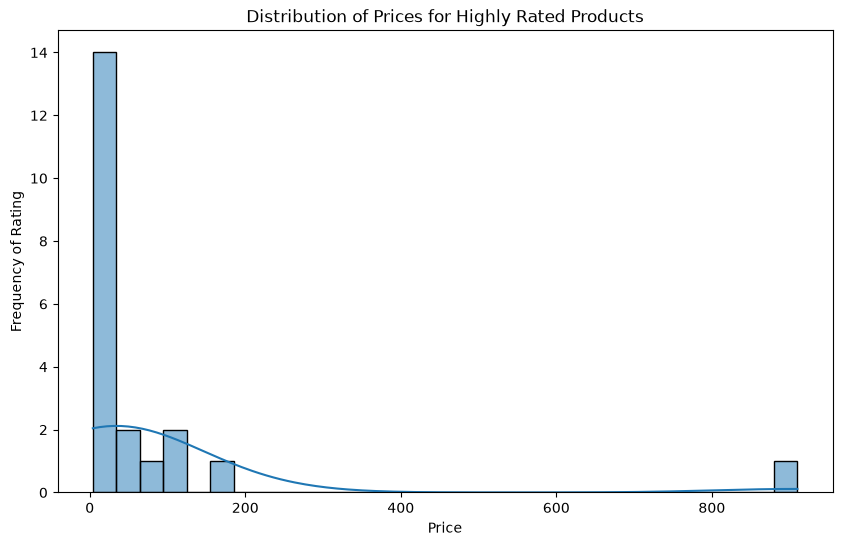

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of Prices
plt.figure(figsize=(10, 6))
sns.histplot(
    top_products_df['price'],
    bins=30,
    kde=True
)
plt.title('Distribution of Prices for Highly Rated Products')
plt.xlabel('Price')
plt.ylabel('Frequency of Rating')
plt.show()

**Let's Reflect...**

Question 6: What trend (if any) do you notice with price and frequency?

In [31]:
_prices = pd.to_numeric(top_products_df['price'], errors='coerce').dropna()
if len(_prices) > 0:
    _median = _prices.median()
    _mean = _prices.mean()
    _share_below_median = (_prices <= _median).mean() * 100
    _skew_note = (
        "The mean is higher than the median, so the distribution is right skewed: most products sit in the lower "
        "price range, with a smaller number of expensive products stretching the tail to the right."
        if _mean > _median else
        "The mean is close to or below the median, so there is no strong right skew in this sample."
    )
    Question6 = (
        f"There are {len(_prices)} highly rated products with a valid price. Prices run from {_prices.min():.2f} to "
        f"{_prices.max():.2f}, with a median of {_median:.2f} and a mean of {_mean:.2f}. {_skew_note} "
        "The frequency is highest for the cheaper price bins and falls away as price rises, so highly rated "
        "products tend to be affordable ones. With only a sample of products this is an indication rather than proof."
    )
else:
    Question6 = "No products met the filter in this sample, so no price trend could be observed."

if len(Question6) > 0:
    print(f"Question answered! You wrote: {Question6}")
else:
    print("Please answer the question")

Question answered! You wrote: There are 21 highly rated products with a valid price. Prices run from 3.99 to 909.99, with a median of 24.63 and a mean of 81.51. The mean is higher than the median, so the distribution is right skewed: most products sit in the lower price range, with a smaller number of expensive products stretching the tail to the right. The frequency is highest for the cheaper price bins and falls away as price rises, so highly rated products tend to be affordable ones. With only a sample of products this is an indication rather than proof.


### Part 6.2: Map the Distribution of Prices for Highly Rated Products as a Scatterplot Graph

Steps to complete:

* Use the `top_products_df` dataframe for the scatterplot graph
* Plot your graph with the `price` for the x axis and `average_rating` on the y axis

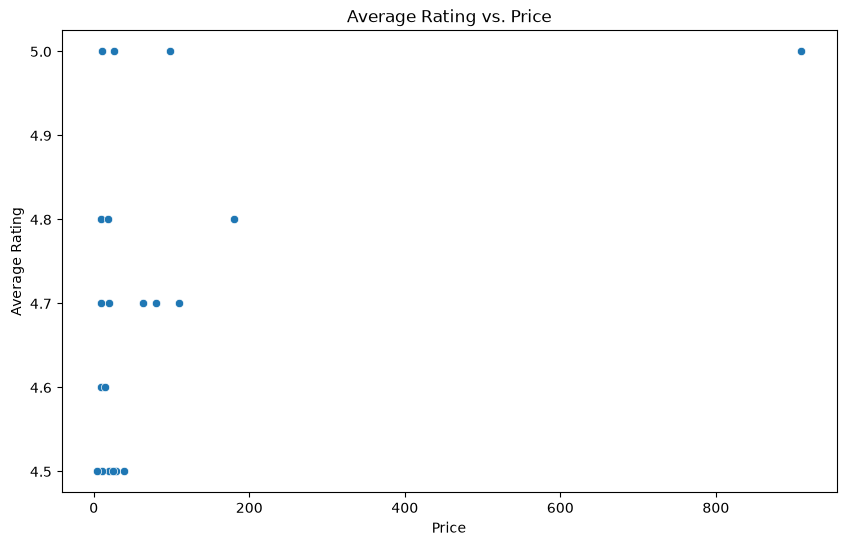

In [32]:
# Average Rating vs. Price
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=top_products_df,
    x='price',
    y='average_rating'
)
plt.title('Average Rating vs. Price')
plt.xlabel('Price')
plt.ylabel('Average Rating')
plt.show()

**Let's Reflect...**

Question 7: What trend (if any) do you notice with price and rating?

In [33]:
_pr = pd.to_numeric(top_products_df['price'], errors='coerce')
_rt = pd.to_numeric(top_products_df['average_rating'], errors='coerce')
if _pr.notna().sum() >= 3 and _rt.nunique() > 1:
    _corr = _pr.corr(_rt)
    _strength = "no clear" if abs(_corr) < 0.3 else ("a moderate" if abs(_corr) < 0.6 else "a strong")
    _direction = "positive" if _corr > 0 else "negative"
    Question7 = (
        f"The correlation between price and average rating is {_corr:.2f}, which shows {_strength} linear relationship"
        + (f" ({_direction})." if abs(_corr) >= 0.3 else ".")
        + " Because the data is already limited to products rated 4.5 or higher, the ratings sit in a narrow band "
        "near the top of the scale at every price point, so higher prices do not obviously buy a better rating and "
        "cheap products can be rated just as highly. Price does not look like a strong predictor of rating in this sample."
    )
else:
    Question7 = "There are too few products with varied ratings in this sample to see a reliable trend between price and rating."

if len(Question7) > 0:
    print(f"Question answered! You wrote: {Question7}")
else:
    print("Please answer the question")

Question answered! You wrote: The correlation between price and average rating is 0.43, which shows a moderate linear relationship (positive). Because the data is already limited to products rated 4.5 or higher, the ratings sit in a narrow band near the top of the scale at every price point, so higher prices do not obviously buy a better rating and cheap products can be rated just as highly. Price does not look like a strong predictor of rating in this sample.


### Part 6.3: Display the Distribution of Ratings and Price Together

For business-facing teams, showing data a couple of different ways is helpful, so we visualize these 2 graphs together.

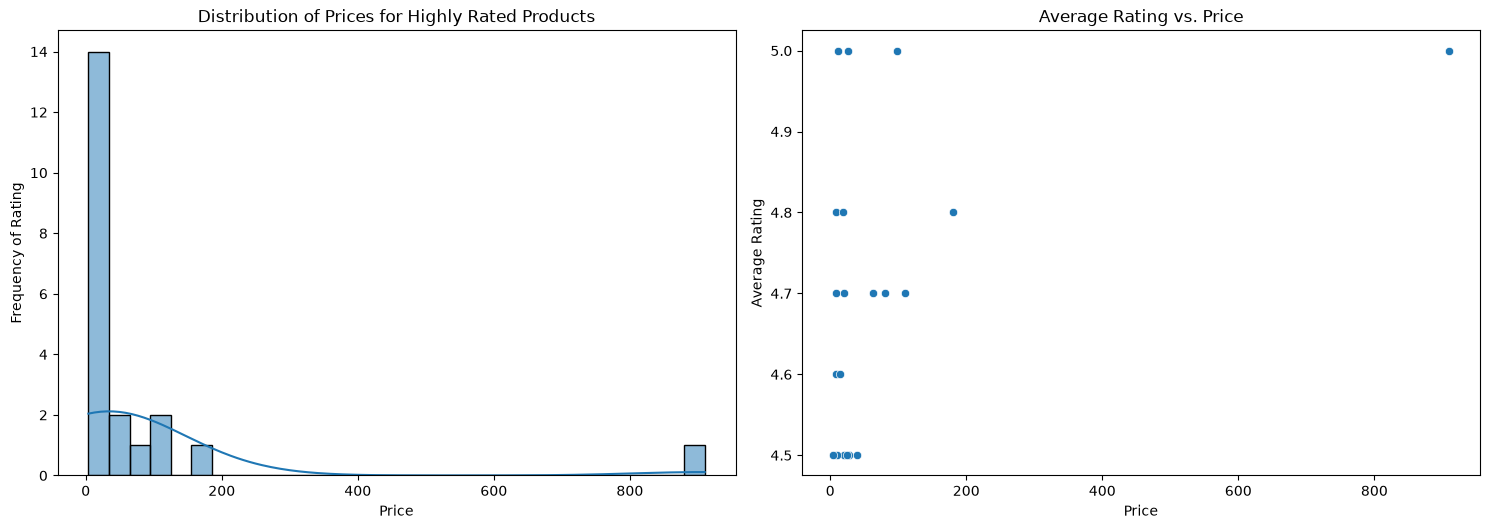

In [34]:
# Create a Dashboard Layout
plt.figure(figsize=(15, 10))

# Subplot 1: Distribution of Prices
plt.subplot(2, 2, 1)
sns.histplot(top_products_df['price'], bins=30, kde=True)
plt.title('Distribution of Prices for Highly Rated Products')
plt.xlabel('Price')
plt.ylabel('Frequency of Rating')

# Subplot 2: Average Rating vs. Price
plt.subplot(2, 2, 2)
sns.scatterplot(data=top_products_df, x='price', y='average_rating')
plt.title('Average Rating vs. Price')
plt.xlabel('Price')
plt.ylabel('Average Rating')

# Feel free to add other visualizations as you like

# Show the Dashboard
plt.tight_layout()
plt.show()

### 6.4: Narrow Down on the Handful of Products that Will be Most Meaningful

Steps to complete:

* Specify a cutoff threshold for the results as float data type `4.7`

In [35]:
# Filter the DataFrame to include only products with an average rating of 4.7 or higher
average_rating_cutoff = 4.7
highly_rated_products_df = top_products_df[top_products_df['average_rating'] >= average_rating_cutoff]

# Display the filtered DataFrame
print(highly_rated_products_df)

                                                title  average_rating   price
14  Novelty Cute Cartoon USB 2.0 Flash Drive Data ...             4.7    8.98
16  ANNKE 4K 16CH Security DVR Recorder with Human...             5.0  909.99
17  BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...             5.0   98.49
24  Polaroid Originals Now Viewfinder i-Type Insta...             4.8  179.99
30  HP Elitebook 8560W New Replacement LCD Screen ...             4.7   63.33
37  Wenlaty Case Compatible with iPad 9th /8th /7t...             4.7   19.99
42  Centon Electronics Flash Memory Card (S1-SDHU1...             4.8    8.99
46  PNY 1TB PRO Elite Class 10 U3 V30 microSDXC Fl...             4.7  109.99
50  JBL FLIP 5 - Waterproof Portable Bluetooth Spe...             4.7   79.90
60  MHYALUDO Silicone Print Case Cover for Apple A...             5.0   10.99
78  CoBak Case for Kindle Paperwhite - All New PU ...             4.8   18.95
97  Monsoon G1/4" to 1/2" ID, 3/4" OD Chain Gun Co...           

Count the number of items in the newly cleaned dataset

In [36]:
# Review the new items in cleaned DataFrame
highly_rated_num_items = highly_rated_products_df.shape[0]
print(f"Number of items in the highly rated DataFrame: {highly_rated_num_items}")

Number of items in the highly rated DataFrame: 12


Calculate the percentage of the newly cleaned items with the function you wrote earlier. The numbers come straight from the counts in this notebook, so there is no need to type them in.

In [37]:
part = float(highly_rated_num_items)
whole = float(num_items_cleaned)

# Calculate and print the percentage
try:
    result = calculate_percentage(part, whole)
    print(f"{part} is {result:.2f}% of {whole}")
except ValueError as e:
    print(e)

12.0 is 57.14% of 21.0


Plot the new Histogram distribution with your highly rated DataFrame:

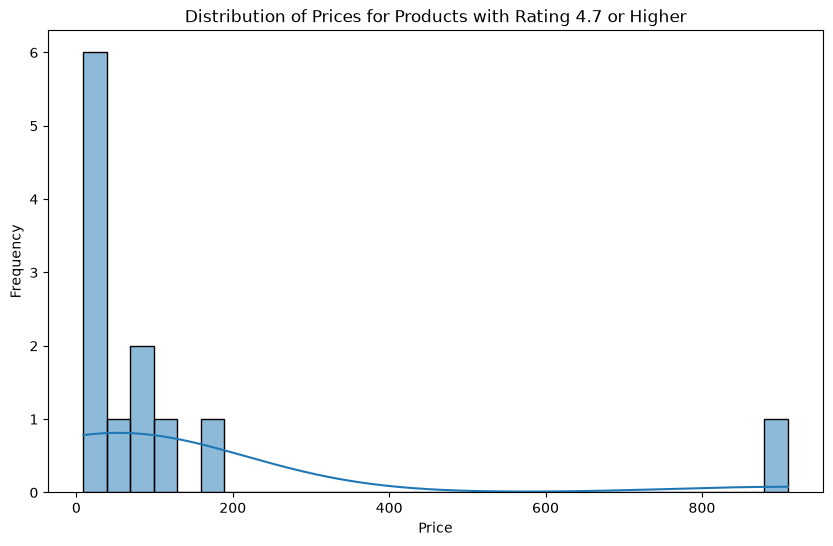

In [38]:
plt.figure(figsize=(10, 6))
sns.histplot(highly_rated_products_df['price'], bins=30, kde=True)
plt.title('Distribution of Prices for Products with Rating 4.7 or Higher')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Plot the new Scatterplot graph with your new highly rated DataFrame:

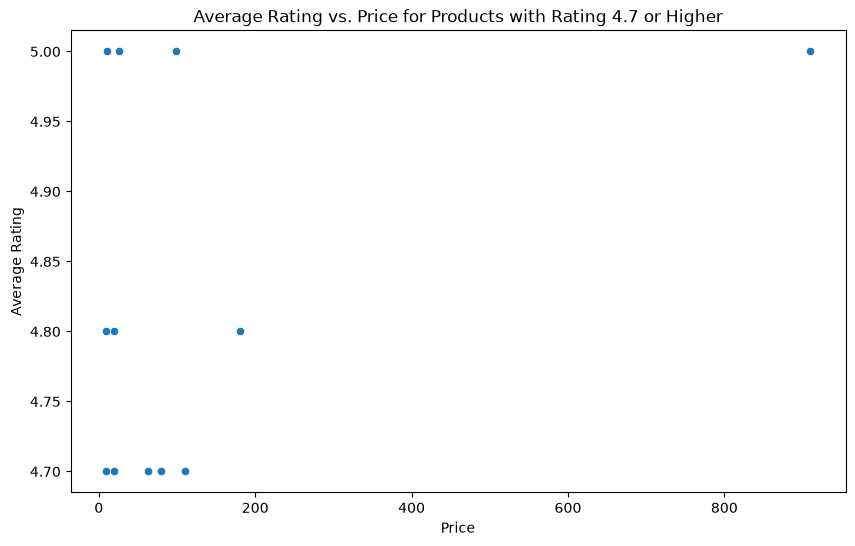

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=highly_rated_products_df, x='price', y='average_rating')
plt.title('Average Rating vs. Price for Products with Rating 4.7 or Higher')
plt.xlabel('Price')
plt.ylabel('Average Rating')
plt.show()

### 6.5: Create a Dashboard of Your New Findings

To share these results with the Machine Learning, Business, and Executive teams we will:

* Filter the DataFrame to products with an average rating of `4.7` or higher
* Sort the DataFrame with the `.sort_values` method by average rating in descending order
* Display the sorted DataFrame as a table
* Create a scatterplot to visualize the relationship between price and average rating for the highly rated products

Steps to complete:

* Set the `highly_rated_products_df_cutoff` with the desired float threshold value
* Update the `highly_rated_products_df` to use the `.sort_values` method
* Fill in the code to display the new sorted DataFrame
* Complete the code to create a scatterplot using Seaborn

Table of Highly Rated Products (Rating 4.7 or Higher, Sorted by Rating):


,title,average_rating,price
16,ANNKE 4K 16CH Security DVR Recorder with Human...,5.0,909.99
17,BIPRA U3 2.5 inch USB 3.0 NTFS Portable Extern...,5.0,98.49
60,MHYALUDO Silicone Print Case Cover for Apple A...,5.0,10.99
97,"Monsoon G1/4"" to 1/2"" ID, 3/4"" OD Chain Gun Co...",5.0,25.71
42,Centon Electronics Flash Memory Card (S1-SDHU1...,4.8,8.99
24,Polaroid Originals Now Viewfinder i-Type Insta...,4.8,179.99
78,CoBak Case for Kindle Paperwhite - All New PU ...,4.8,18.95
14,Novelty Cute Cartoon USB 2.0 Flash Drive Data ...,4.7,8.98
46,PNY 1TB PRO Elite Class 10 U3 V30 microSDXC Fl...,4.7,109.99
37,Wenlaty Case Compatible with iPad 9th /8th /7t...,4.7,19.99


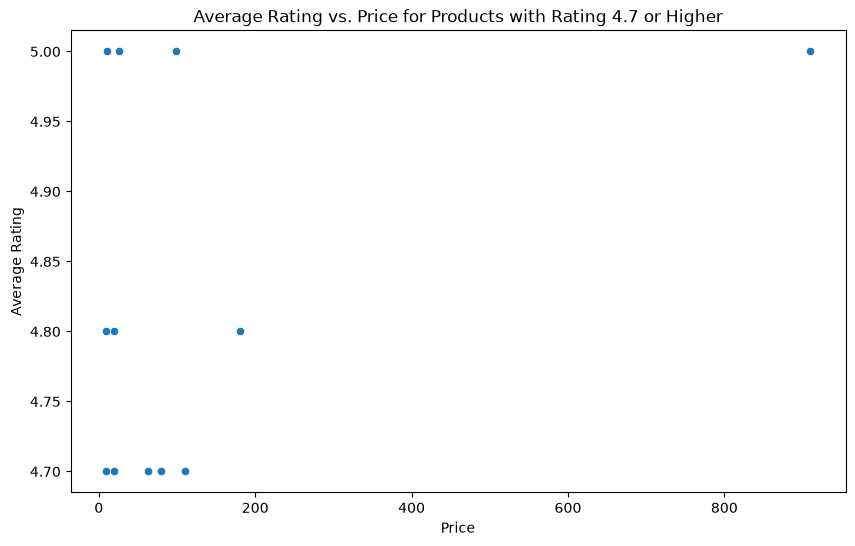

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Filter the DataFrame to include only products with an average rating of 4.7 or higher
highly_rated_products_df_cutoff = 4.7
highly_rated_products_df = top_products_df[top_products_df['average_rating'] >= highly_rated_products_df_cutoff]

# Sort the DataFrame by average_rating in descending order
highly_rated_products_df = highly_rated_products_df.sort_values(by='average_rating', ascending=False)

# Display the sorted DataFrame as a table
print("Table of Highly Rated Products (Rating 4.7 or Higher, Sorted by Rating):")
display(highly_rated_products_df)

# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=highly_rated_products_df, x='price', y='average_rating')
plt.title('Average Rating vs. Price for Products with Rating 4.7 or Higher')
plt.xlabel('Price')
plt.ylabel('Average Rating')
plt.show()

## Wrap Up

To wrap up, let's output all of your responses to the questions earlier into a `.txt` file. The code:

* creates a list of the questions to group all of your answers together
* creates a file name as a string called `output_file` where your responses are written
* uses a for loop inside a `with` statement to write each question and response as a line in the text file
* uses `print` to let us know when the file has been created

In [41]:
Name = "Dennis O'Higgins"

if len(Name) > 0:
    print(f"You added your name: {Name}")
else:
    print("Please answer the question")

# Collect all the questions into a list
questions = [Question1, Question2, Question3, Question4, Question5, Question6, Question7]

# Define the file name where your answers will be saved to
output_file = 'user_inputs.txt'

# Write the project details and questions to the output file
with open(output_file, 'w') as file:
    # Write the project title and your name
    file.write("Transformational AI: Analyzing Ecommerce Large Datasets for Machine Learning\n")
    file.write(f"Completed by: {Name}\n")
    file.write("-------------------------------------\n\n")

    # Write each question and its response on subsequent line
    for i, question in enumerate(questions, start=1):
        file.write(f"Question {i}: {question}\n")

print(f"All questions have been written to {output_file}")

You added your name: Dennis O'Higgins
All questions have been written to user_inputs.txt


## Be Sure to Download Your Great Work

You should see these in the file directory on the left:

* This Jupyter Notebook with your cell outputs included
* Your `user_inputs.txt` file with your answers to all reflection questions
* Your `top_products.csv` dataset
* Your `top_products.parquet` dataset